In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/cybersecurity.csv")

print(df.shape)

(10000, 13)


In [2]:
df.head()

,timestamp,src_ip,dst_ip,src_port,dst_port,protocol,bytes_sent,bytes_received,user_agent,url,is_internal_traffic,label,attack_type
0,2025-10-01 00:12:54,188.176.27.165,253.240.113.218,56377,445,TCP,8029,17204,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://webmail.corp/login?id=385071,False,0,benign
1,2025-10-01 00:23:43,68.59.26.43,212.75.38.111,51165,1433,TCP,676368,2643374,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://portal.example.org/owa/auth/logon.aspx...,False,0,benign
2,2025-10-01 00:25:46,119.204.243.78,90.28.90.234,14948,1433,TCP,316502,38571,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,False,0,benign
3,2025-10-01 00:27:21,122.119.194.175,175.140.78.230,36097,443,TCP,70933,21935,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://webmail.corp/phpmyadmin?id=114701,False,0,benign
4,2025-10-01 00:40:09,181.199.242.68,55.99.177.69,445,21255,TCP,12721,9939,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://portal.example.org/config.php?id=345569,False,0,benign


In [4]:
df.tail()

,timestamp,src_ip,dst_ip,src_port,dst_port,protocol,bytes_sent,bytes_received,user_agent,url,is_internal_traffic,label,attack_type
9995,2025-12-29 22:56:36,68.171.102.131,77.36.90.5,43285,3306,UDP,1053,401,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,NaN,False,0,benign
9996,2025-12-29 23:03:05,213.54.194.229,216.34.37.197,3389,445,TCP,10597,16670,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,https://app.company.in/api/v1/users?id=525850,False,0,benign
9997,2025-12-29 23:11:46,211.68.159.72,149.12.197.127,18395,53,TCP,2857,6031,sqlmap/1.8,NaN,False,1,xss
9998,2025-12-29 23:20:46,19.12.213.100,243.249.117.224,31882,80,TCP,6062,3504,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,https://app.company.in/manager/html?id=497838,False,0,benign
9999,2025-12-29 23:26:12,161.251.147.82,107.163.89.174,52607,3389,TCP,335446,442720,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://webmail.corp/api/v1/users?id=315734,False,0,benign


In [5]:
df.info() # 3232 missing values in url >> 32.3% of the column is missing

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   timestamp            10000 non-null  str  
 1   src_ip               10000 non-null  str  
 2   dst_ip               10000 non-null  str  
 3   src_port             10000 non-null  int64
 4   dst_port             10000 non-null  int64
 5   protocol             10000 non-null  str  
 6   bytes_sent           10000 non-null  int64
 7   bytes_received       10000 non-null  int64
 8   user_agent           10000 non-null  str  
 9   url                  6768 non-null   str  
 10  is_internal_traffic  10000 non-null  bool 
 11  label                10000 non-null  int64
 12  attack_type          10000 non-null  str  
dtypes: bool(1), int64(5), str(7)
memory usage: 947.4 KB


In [6]:
df.isna()

,timestamp,src_ip,dst_ip,src_port,dst_port,protocol,bytes_sent,bytes_received,user_agent,url,is_internal_traffic,label,attack_type
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,False,False,False,False,False,False,False,False,False,True,False,False,False
9996,False,False,False,False,False,False,False,False,False,False,False,False,False
9997,False,False,False,False,False,False,False,False,False,True,False,False,False
9998,False,False,False,False,False,False,False,False,False,False,False,False,False


In [7]:
df["label"].value_counts()

label
0    9600
1     400
Name: count, dtype: int64

In [8]:
df["label"].value_counts(normalize=True) * 100  
#Normal → 96%
#Attack → 4%

label
0    96.0
1     4.0
Name: proportion, dtype: float64

In [9]:
df["attack_type"].value_counts()

attack_type
benign                 9600
brute-force             108
port-scan                81
sql-injection            64
xss                      34
credential-stuffing      28
ddos                     27
command-injection        26
exploit-attempt          22
c2                       10
Name: count, dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.nunique()

timestamp               9998
src_ip                 10000
dst_ip                 10000
src_port                7647
dst_port                 449
protocol                   3
bytes_sent              9280
bytes_received          9541
user_agent                13
url                     6768
is_internal_traffic        2
label                      2
attack_type               10
dtype: int64

In [12]:
print("Protocol:")
print(df["protocol"].value_counts())

print("\nInternal Traffic:")
print(df["is_internal_traffic"].value_counts())

# now we are sure that protocol and Internal Traffic can be used as features

Protocol:
protocol
TCP     7765
UDP     1910
ICMP     325
Name: count, dtype: int64

Internal Traffic:
is_internal_traffic
False    8466
True     1534
Name: count, dtype: int64


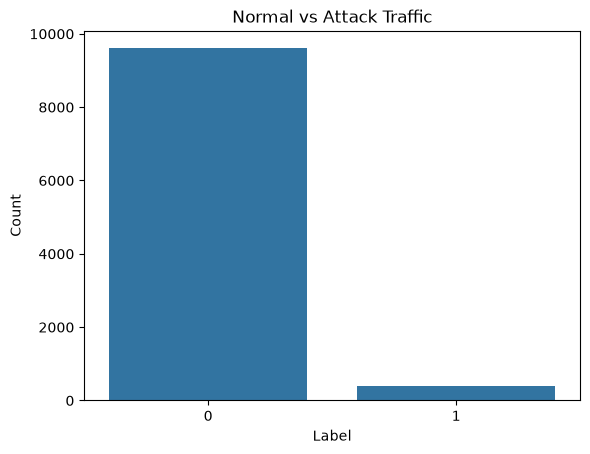

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x="label")

plt.title("Normal vs Attack Traffic")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [14]:
df.groupby("label")[["bytes_sent", "bytes_received"]].agg(["mean", "median"])
# 0 = normal , 1 = attack

#

bytes_sent          bytes_received         
               mean   median           mean   median
label                                               
0      7.917183e+04  22089.5   1.677655e+05  37817.5
1      1.631307e+06  16965.0   2.525835e+06  29373.5

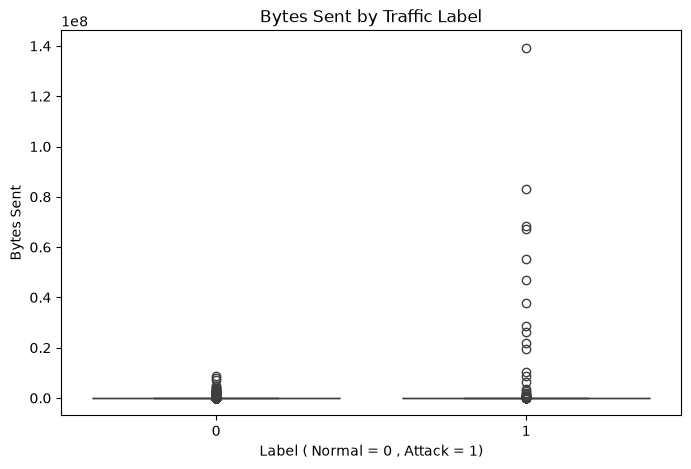

In [15]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="label", y="bytes_sent")

plt.title("Bytes Sent by Traffic Label")
plt.xlabel("Label ( Normal = 0 , Attack = 1)")
plt.ylabel("Bytes Sent")

plt.show()

# We will work Binary Classification  >> 0 = Normal ,,, >> 1 >> Attack

In [16]:
# our dataset says Normal is 96% so the model accuracy needs to be above 96% 

In [17]:
#Numerical Data :  src_port , dst_port , bytes_sent , bytes_received 
# Categorical : protocol , user_agent , url , src_ip , dst_ip 
# Boolean : is_internal_traffic
# Target : label 


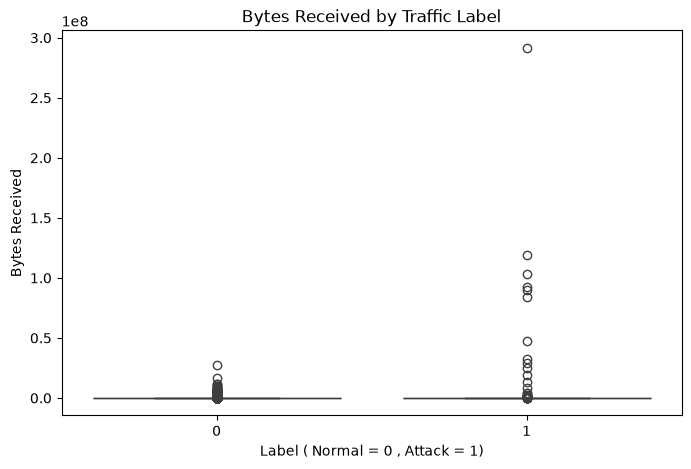

In [18]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="label", y="bytes_received")

plt.title("Bytes Received by Traffic Label")
plt.xlabel("Label ( Normal = 0 , Attack = 1)")
plt.ylabel("Bytes Received")

plt.show()

In [19]:
df.groupby("label")[["src_port", "dst_port"]].agg(["mean", "median"])

src_port              dst_port       
               mean   median         mean median
label                                           
0      27381.686354  25861.0  2068.898958  443.0
1      19145.120000   9711.0  1028.437500  266.0

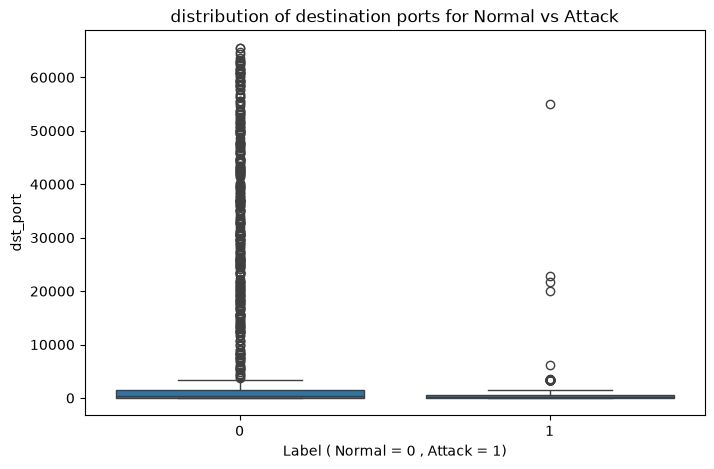

In [20]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="label", y="dst_port")

plt.title("distribution of destination ports for Normal vs Attack")
plt.xlabel("Label ( Normal = 0 , Attack = 1)")
plt.ylabel("dst_port")

plt.show()

In [21]:
df.groupby(["protocol", "label"]).size()

protocol  label
ICMP      0         307
          1          18
TCP       0        7451
          1         314
UDP       0        1842
          1          68
dtype: int64

In [29]:
AttackPerc=df.groupby("protocol")["label"].value_counts(normalize=True) * 100

AttackPerc
#ICMP protocol has the highest attack percentage >> 5.54%

protocol  label
ICMP      0        94.461538
          1         5.538462
TCP       0        95.956214
          1         4.043786
UDP       0        96.439791
          1         3.560209
Name: proportion, dtype: float64

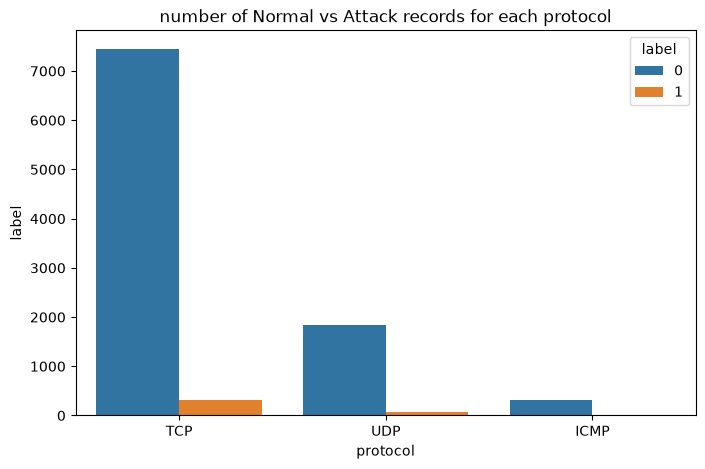

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="protocol",
    hue="label"
)
plt.title("number of Normal vs Attack records for each protocol")
plt.xlabel("protocol")
plt.ylabel("label")
plt.show()

#looks in the graph like that TCP has higher attack but its just because we have huge num of TCP in the dataset 


In [33]:
percentage = df.groupby("protocol")["label"].value_counts(normalize=True).unstack() * 100

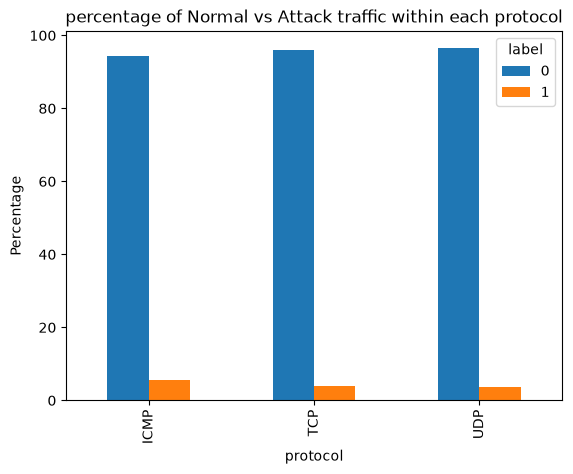

In [ ]:
percentage.plot(kind="bar")

plt.title("percentage of Normal vs Attack traffic within each protocol")
plt.xlabel("protocol")
plt.ylabel("Percentage")
plt.show()

# here we will find the ICMP attack is higher cause its the percentage figureS

In [36]:
# we need to know if attack traffic is common in internal traffic or external traffic

df.groupby(["is_internal_traffic", "label"]).size()

is_internal_traffic  label
False                0        8126
                     1         340
True                 0        1474
                     1          60
dtype: int64

In [39]:
df.groupby("is_internal_traffic") ["label"].value_counts(normalize=True) * 100


is_internal_traffic  label
False                0        95.983936
                     1         4.016064
True                 0        96.088657
                     1         3.911343
Name: proportion, dtype: float64

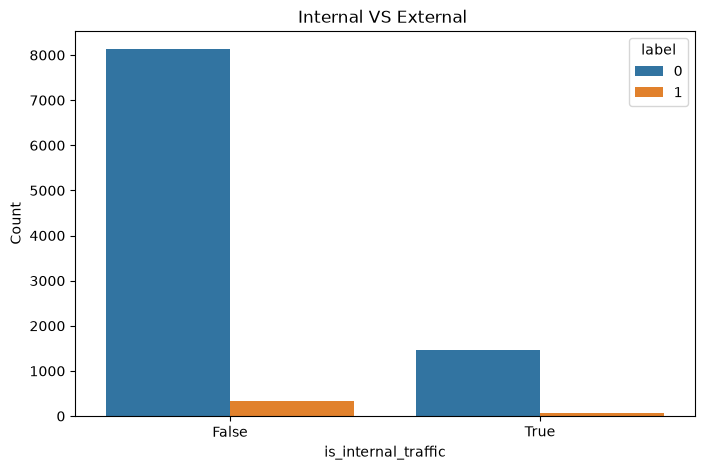

In [42]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="is_internal_traffic",
    hue="label"
)
plt.title("Internal VS External ")
plt.xlabel("is_internal_traffic")
plt.ylabel("Count")
plt.show()



In [43]:
# we need to know if there is a specific user_agent has higher attack

df.groupby("user_agent")["label"].value_counts(normalize=True) * 100

user_agent                                                                                                                               label
Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 Safari/537.36                    0         97.303823
                                                                                                                                         1          2.696177
Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36                          0         97.223829
                                                                                                                                         1          2.776171
Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:109.0) Gecko/20100101 Firefox/115.0                                                         0         96.173469
                                                                        

In [49]:
result = df.groupby("user_agent")["label"].value_counts(normalize=True).reset_index()

result

,user_agent,label,proportion
0,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,0,0.973038
1,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1,0.026962
2,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,0,0.972238
3,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1,0.027762
4,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,0,0.961735
5,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,1,0.038265
6,Mozilla/5.0 (compatible; Googlebot/2.1; +http:...,0,0.963519
7,Mozilla/5.0 (compatible; Googlebot/2.1; +http:...,1,0.036481
8,Mozilla/5.0 (compatible; sqlmap/1.7),1,1.000000
9,Mozilla/5.0 (iPhone; CPU iPhone OS 16_6 like M...,0,0.976763


In [50]:
attack_only = result[result["label"] == 1]

In [51]:
attack_only

,user_agent,label,proportion
1,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1,0.026962
3,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1,0.027762
5,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,1,0.038265
7,Mozilla/5.0 (compatible; Googlebot/2.1; +http:...,1,0.036481
8,Mozilla/5.0 (compatible; sqlmap/1.7),1,1.000000
10,Mozilla/5.0 (iPhone; CPU iPhone OS 16_6 like M...,1,0.023237
11,curl/7.81.0,1,1.000000
13,curl/8.4.0,1,0.033499
14,python-requests/2.28,1,1.000000
16,python-requests/2.31.0,1,0.025818


In [55]:
attack_only.sort_values("proportion",ascending=False )

,user_agent,label,proportion
8,Mozilla/5.0 (compatible; sqlmap/1.7),1,1.000000
14,python-requests/2.28,1,1.000000
11,curl/7.81.0,1,1.000000
20,sqlmap/1.8,1,0.262712
22,zgrab/0.x,1,0.228070
5,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,1,0.038265
7,Mozilla/5.0 (compatible; Googlebot/2.1; +http:...,1,0.036481
13,curl/8.4.0,1,0.033499
3,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1,0.027762
1,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1,0.026962


In [60]:
agent_counts =df["user_agent"].value_counts()
agent_counts


user_agent
Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36                            3458
Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 Safari/537.36                      2485
Mozilla/5.0 (iPhone; CPU iPhone OS 16_6 like Mac OS X) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/16.6 Mobile/15E148 Safari/604.1    1205
curl/8.4.0                                                                                                                                  806
python-requests/2.31.0                                                                                                                      581
Mozilla/5.0 (compatible; Googlebot/2.1; +http://www.google.com/bot.html)                                                                    466
Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:109.0) Gecko/20100101 Firefox/115.0                                             

In [62]:
result["total_count"] = result["user_agent"].map(agent_counts)

result.sort_values("proportion",ascending=False )

,user_agent,label,proportion,total_count
14,python-requests/2.28,1,1.000000,23
11,curl/7.81.0,1,1.000000,21
8,Mozilla/5.0 (compatible; sqlmap/1.7),1,1.000000,27
17,python-urllib/3.9,0,0.976974,304
9,Mozilla/5.0 (iPhone; CPU iPhone OS 16_6 like M...,0,0.976763,1205
15,python-requests/2.31.0,0,0.974182,581
0,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,0,0.973038,2485
2,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,0,0.972238,3458
12,curl/8.4.0,0,0.966501,806
6,Mozilla/5.0 (compatible; Googlebot/2.1; +http:...,0,0.963519,466


In [63]:
attack_only = result[result["label"] ==1]

In [64]:
attack_only.sort_values("proportion" , ascending= False)

,user_agent,label,proportion,total_count
8,Mozilla/5.0 (compatible; sqlmap/1.7),1,1.000000,27
14,python-requests/2.28,1,1.000000,23
11,curl/7.81.0,1,1.000000,21
20,sqlmap/1.8,1,0.262712,118
22,zgrab/0.x,1,0.228070,114
5,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,1,0.038265,392
7,Mozilla/5.0 (compatible; Googlebot/2.1; +http:...,1,0.036481,466
13,curl/8.4.0,1,0.033499,806
3,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1,0.027762,3458
1,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1,0.026962,2485


# What Is Done Is :
✅ Overall dataset / shape
✅ Missing values
✅ Duplicates
✅ Class imbalance
✅ Attack types
✅ Protocol distribution
✅ Protocol vs Attack percentage
✅ Internal vs External traffic
✅ User-agent vs Attack
✅ Bytes sent/received + outliers